## Sentimental Analysis

* Postive Sentiment 
* Negative Sentiment 
* Neutral Sentiment

### 1. Rule-Based or Lexical Based Sentimental Analysis

* TextBlob [-1, 0 , 1]

In [1]:
sentence_1 = "i had a great time at the movie it was really funny"
sentence_2 = "i had a great time at the movie but the parking was terrible"
sentence_3 = "i had a great time at the movie but the parking wasn't great"
sentence_4 = "i went to see a movie"

In [2]:
from textblob import TextBlob 

print(sentence_1)
sentimental_score_1 = TextBlob(sentence_1)
print(sentimental_score_1.sentiment.polarity)

i had a great time at the movie it was really funny
0.525


In [3]:
print(sentence_2)
sentimental_score_2 = TextBlob(sentence_2)
print(sentimental_score_2.sentiment.polarity)

i had a great time at the movie but the parking was terrible
-0.09999999999999998


In [4]:
print(sentence_3)
sentimental_score_3 = TextBlob(sentence_3)
print(sentimental_score_3.sentiment.polarity)

i had a great time at the movie but the parking wasn't great
0.8


In [5]:
print(sentence_4)
sentimental_score_4 = TextBlob(sentence_4)
print(sentimental_score_4.sentiment.polarity)

i went to see a movie
0.0


* VADER

In [7]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [8]:
vader_sentiment = SentimentIntensityAnalyzer()

print(sentence_1)
print(vader_sentiment.polarity_scores(sentence_1))

i had a great time at the movie it was really funny
{'neg': 0.0, 'neu': 0.578, 'pos': 0.422, 'compound': 0.807}


In [9]:
print(sentence_2)
print(vader_sentiment.polarity_scores(sentence_2))

i had a great time at the movie but the parking was terrible
{'neg': 0.234, 'neu': 0.621, 'pos': 0.144, 'compound': -0.3818}


In [10]:
print(sentence_3)
print(vader_sentiment.polarity_scores(sentence_3))

i had a great time at the movie but the parking wasn't great
{'neg': 0.247, 'neu': 0.611, 'pos': 0.142, 'compound': -0.4387}


In [11]:
print(sentence_4)
print(vader_sentiment.polarity_scores(sentence_4))

i went to see a movie
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}


### 2. Pre-trained Transformer

In [12]:
import transformers 
from transformers import pipeline

In [13]:
sentiment_pipeline = pipeline('sentiment-analysis')

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use mps:0


In [14]:
print(sentence_1)
sentiment_pipeline(sentence_1)

i had a great time at the movie it was really funny


[{'label': 'POSITIVE', 'score': 0.9998176693916321}]

In [15]:
print(sentence_2)
sentiment_pipeline(sentence_2)

i had a great time at the movie but the parking was terrible


[{'label': 'NEGATIVE', 'score': 0.9977464079856873}]

In [16]:
specific_model = pipeline('sentiment-analysis', model='finiteautomata/bertweet-base-sentiment-analysis')

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
Device set to use mps:0


In [17]:
print(sentence_1)
specific_model(sentence_1)

i had a great time at the movie it was really funny


[{'label': 'POS', 'score': 0.9923344254493713}]

In [18]:
print(sentence_2)
specific_model(sentence_2)

i had a great time at the movie but the parking was terrible


[{'label': 'NEG', 'score': 0.5355538725852966}]

In [19]:
print(sentence_3)
specific_model(sentence_3)

i had a great time at the movie but the parking wasn't great


[{'label': 'POS', 'score': 0.6234404444694519}]

In [20]:
print(sentence_4)
specific_model(sentence_4)

i went to see a movie


[{'label': 'NEU', 'score': 0.9007406830787659}]

### Practical Tasks: Sentimental Analysis

In [21]:
import pandas as pd
import numpy as np 
import re 
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers 
from transformers import pipeline

In [22]:
df = pd.read_csv('Datasets/book_reviews_sample.csv')
df.head()

,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1


In [23]:
df['reviewText'][0]

'Clean and funny. A bit busy with all the different plots going on. But overall a good read. Bye now.'

In [24]:
df['reviewText_clean'] = df['reviewText'].str.lower()

In [25]:
df['reviewText_clean'] = df.apply(lambda x: re.sub(r"([^\w\s])", '', x['reviewText_clean']), axis=1)

In [26]:
df.head()

,index,reviewText,rating,reviewText_clean
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...


In [27]:
df['textblob_sentiment_score'] = df['reviewText_clean'].apply(lambda review: TextBlob(review).sentiment.polarity)
df.head()

,index,reviewText,rating,reviewText_clean,textblob_sentiment_score
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.236111
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.430000
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.187500
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.109091
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.277778


In [30]:
bins = [-1, -0.1, 0.1, 1]
names = ['negative', 'neutral', 'positive']

df['textblob_sentiment_label'] = pd.cut(df['textblob_sentiment_score'], bins, labels=names)
df.head()

,index,reviewText,rating,reviewText_clean,textblob_sentiment_score,textblob_sentiment_label
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.236111,positive
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.430000,positive
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.187500,positive
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.109091,positive
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.277778,negative


<Axes: xlabel='textblob_sentiment_label'>

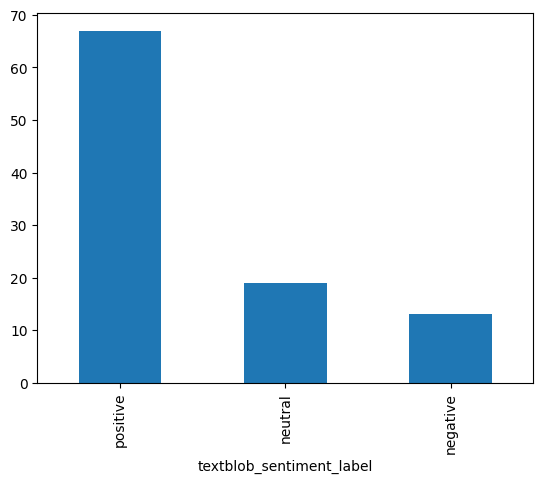

In [31]:
df['textblob_sentiment_label'].value_counts().plot.bar()

In [32]:
vader_sentiment = SentimentIntensityAnalyzer()

df['vader_sentiment_scores'] = df['reviewText_clean'].apply(lambda review: vader_sentiment.polarity_scores(review)['compound'])
df.head()


,index,reviewText,rating,reviewText_clean,textblob_sentiment_score,textblob_sentiment_label,vader_sentiment_scores
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.236111,positive,0.7684
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.430000,positive,0.9325
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.187500,positive,0.6740
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.109091,positive,0.6652
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.277778,negative,-0.4767


In [33]:
df['vader_sentiment_label'] = pd.cut(df['vader_sentiment_scores'], bins, labels=names)
df.head()

,index,reviewText,rating,reviewText_clean,textblob_sentiment_score,textblob_sentiment_label,vader_sentiment_scores,vader_sentiment_label
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.236111,positive,0.7684,positive
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.430000,positive,0.9325,positive
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.187500,positive,0.6740,positive
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.109091,positive,0.6652,positive
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.277778,negative,-0.4767,negative


In [35]:
transformer_pipeline = pipeline('sentiment-analysis')

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


Device set to use mps:0


In [36]:
transformer_labels = []

for review in df['reviewText_clean'].values:
    sentiment_list = transformer_pipeline(review)
    sentiment_label = [sent['label'] for sent in sentiment_list]
    transformer_labels.append(sentiment_label)

df['transformer_sentiment_labels'] = transformer_labels

In [37]:
df.head()

,index,reviewText,rating,reviewText_clean,textblob_sentiment_score,textblob_sentiment_label,vader_sentiment_scores,vader_sentiment_label,transformer_sentiment_labels
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.236111,positive,0.7684,positive,[POSITIVE]
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.430000,positive,0.9325,positive,[POSITIVE]
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.187500,positive,0.6740,positive,[NEGATIVE]
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.109091,positive,0.6652,positive,[NEGATIVE]
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.277778,negative,-0.4767,negative,[NEGATIVE]


### LDA (Latent Dirichlet Allocation)

In [1]:
import pandas as pd 
import re 
from nltk.corpus import stopwords 
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import gensim
import gensim.corpora as corpora

In [3]:
data = pd.read_csv('Datasets/news_articles.csv')

In [4]:
data.head()

,id,title,content
0,25626,"One Weight-Loss Approach Fits All? No, Not Eve...","Dr. Frank Sacks, a professor of nutrition at H..."
1,19551,South Carolina Stuns Baylor to Reach the Round...,South Carolina’s win over Duke was not only ...
2,25221,"U.S. Presidential Race, Apple, Gene Wilder: Yo...",(Want to get this briefing by email? Here’s th...
3,18026,"His Predecessor Gone, Gambia’s New President F...","BANJUL, Gambia — A week after he was inaugu..."
4,21063,‘Harry Potter and the Cursed Child’ Goes From ...,The biggest book of the summer isn’t a blockbu...


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       100 non-null    int64 
 1   title    100 non-null    object
 2   content  100 non-null    object
dtypes: int64(1), object(2)
memory usage: 2.5+ KB


In [6]:
articles = data['content']

In [12]:
cleaned_articles = []
ps = PorterStemmer()

for text in articles.values:
    text = text.lower()
    text = re.sub(r'([^\w\s])', '', text)
    tokens = word_tokenize(text)
    cleaned_tokens = [ps.stem(token) for token in tokens if token not in stopwords.words('english')]
    cleaned_articles.append(cleaned_tokens)
print(cleaned_articles)


[['dr', 'frank', 'sack', 'professor', 'nutrit', 'harvard', 'like', 'challeng', 'audienc', 'give', 'lectur', 'obes', 'want', 'make', 'great', 'discoveri', 'tell', 'figur', 'peopl', 'lose', '50', 'pound', 'diet', 'other', 'diet', 'gain', 'pound', 'show', 'data', 'studi', 'found', 'exactli', 'effect', 'dr', 'sackss', 'challeng', 'question', 'center', 'obes', 'research', 'today', 'two', 'peopl', 'amount', 'excess', 'weight', 'age', 'socioeconom', 'class', 'race', 'gender', 'yet', 'treatment', 'work', 'one', 'noth', 'problem', 'research', 'say', 'obes', 'precursor', 'overweight', 'one', 'diseas', 'instead', 'like', 'cancer', 'mani', 'look', 'two', 'peopl', 'amount', 'excess', 'bodi', 'weight', 'put', 'weight', 'differ', 'reason', 'said', 'dr', 'arya', 'sharma', 'medic', 'director', 'obes', 'program', 'univers', 'alberta', 'explain', 'treatment', 'difficult', 'result', 'wildli', 'variabl', 'explain', 'prevent', 'effort', 'often', 'fail', 'obes', 'mani', 'diseas', 'said', 'dr', 'lee', 'kaplan

In [13]:
cleaned_articles

[['dr',
  'frank',
  'sack',
  'professor',
  'nutrit',
  'harvard',
  'like',
  'challeng',
  'audienc',
  'give',
  'lectur',
  'obes',
  'want',
  'make',
  'great',
  'discoveri',
  'tell',
  'figur',
  'peopl',
  'lose',
  '50',
  'pound',
  'diet',
  'other',
  'diet',
  'gain',
  'pound',
  'show',
  'data',
  'studi',
  'found',
  'exactli',
  'effect',
  'dr',
  'sackss',
  'challeng',
  'question',
  'center',
  'obes',
  'research',
  'today',
  'two',
  'peopl',
  'amount',
  'excess',
  'weight',
  'age',
  'socioeconom',
  'class',
  'race',
  'gender',
  'yet',
  'treatment',
  'work',
  'one',
  'noth',
  'problem',
  'research',
  'say',
  'obes',
  'precursor',
  'overweight',
  'one',
  'diseas',
  'instead',
  'like',
  'cancer',
  'mani',
  'look',
  'two',
  'peopl',
  'amount',
  'excess',
  'bodi',
  'weight',
  'put',
  'weight',
  'differ',
  'reason',
  'said',
  'dr',
  'arya',
  'sharma',
  'medic',
  'director',
  'obes',
  'program',
  'univers',
  'alber

In [15]:
dictionary = corpora.Dictionary(cleaned_articles)

In [16]:
print(dictionary)

Dictionary<8691 unique tokens: ['10', '100', '108', '15', '155']...>


In [17]:
doc_term = [dictionary.doc2bow(text) for text in cleaned_articles]
print(doc_term)

[[(0, 1), (1, 1), (2, 1), (3, 2), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 2), (15, 1), (16, 1), (17, 2), (18, 1), (19, 1), (20, 3), (21, 3), (22, 1), (23, 3), (24, 2), (25, 4), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 2), (38, 1), (39, 1), (40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 2), (48, 2), (49, 1), (50, 2), (51, 2), (52, 1), (53, 1), (54, 2), (55, 1), (56, 2), (57, 6), (58, 1), (59, 1), (60, 1), (61, 4), (62, 2), (63, 1), (64, 1), (65, 2), (66, 1), (67, 1), (68, 1), (69, 1), (70, 5), (71, 4), (72, 1), (73, 1), (74, 1), (75, 2), (76, 2), (77, 1), (78, 2), (79, 2), (80, 1), (81, 1), (82, 1), (83, 4), (84, 2), (85, 1), (86, 1), (87, 3), (88, 1), (89, 3), (90, 1), (91, 2), (92, 3), (93, 6), (94, 1), (95, 1), (96, 1), (97, 1), (98, 1), (99, 1), (100, 1), (101, 1), (102, 1), (103, 2), (104, 5), (105, 1), (106, 2), (107, 1), (108, 1), (109, 3), (110, 4)

In [18]:
num_topics = 2

lda_model = gensim.models.LdaModel(corpus=doc_term, id2word=dictionary, num_topics=num_topics)